# Causal Entropic Forces

Here's how the algorithm works:
1. From the current state, sample `NUM_ROLLOUTS`
2. Estimate the probability of sampling trajectory i `p(traj_i)` using kernel density estimation
3. Define the volume of trajectory i as `vol_i = 1 / p(traj_i)`
4. Calculate the normalized volume of a trajectory `norm_vol_i = vol_i / \sum_i vol_i`
5. Calculate the causal entropic force `2 * T_C / T_R \mean_i f_i * \log norm_vol_i`, where `f_i` is the initial force of trajectory i and the value `T_C / T_R` governs how much more you want to exploit (acting following the entropic force) vs explore (sampling a trajectory)
6. Use the causal entropic force to update the current state

In [1]:
import os
os.environ["JAX_MPS_ASYNC_DISPATCH"] = "1"

In [2]:
import jax

from jax import numpy as jnp

import numpy as np

import scipy

from matplotlib import pyplot as plt
from matplotlib import patches as patches
from matplotlib import cm

import copy
import time
import datetime

In [3]:
key = jax.random.key(0)

dtype = jnp.float32

Platform 'mps' is experimental and not all JAX functionality may be correctly supported!
[jax-mps] JAX_MPS_ASYNC_DISPATCH is ON: async dispatch enabled — may be much faster, but experimental and may break. Unset it for safe synchronous execution.


In [4]:
T_R     = 4e5  # temperature of random agent (K)
T_C     = 2e6  # temperature of causal agent (K)
TAU     = 10.  # simulation time horizon (seconds)
EPSILON = .025 # timesteps (seconds)

NUM_ROLLOUTS = 1000

SUBSAMPLING = True
NUM_SUBSAMPLES = 5

KDE_CHUNK_SIZE = 100

In [5]:
M     = 1e-21                                # mass (kg)
L     = 400                                  # length (meters) 
Q_MIN = jnp.array([0. , 0.  ], dtype=dtype)  # minimum box displacements
Q_MAX = jnp.array([L  , L/5.], dtype=dtype)  # maximum box displacements
P_MAX = M * jnp.abs(Q_MAX - Q_MIN) / EPSILON # maximum momentum

In [6]:
timesteps = int(TAU / EPSILON)
select_rate = int(timesteps / NUM_SUBSAMPLES)
select_rate = jnp.maximum(1, select_rate)

In [7]:
scale = np.sqrt(M * scipy.constants.Boltzmann * T_R) / EPSILON

In [8]:
def step_p(f):
    new_p = jnp.clip(f * EPSILON, -P_MAX, P_MAX)
    return new_p

def step_q(q, p, new_p):
    new_q = q  +  .5 * EPSILON * (p + new_p) / M
    return new_q

def enforce_elastic_collisions(p, q):
    reflect_min = q < Q_MIN
    reflect_max = q > Q_MAX
    q = jnp.where(reflect_min, 2 * Q_MIN - q, q)
    q = jnp.where(reflect_max, 2 * Q_MAX - q, q)
    p = jnp.where(reflect_min | reflect_max, -p, p)
    return p, q

def step_phase_space(p, q, f):
    new_p        = step_p(f)
    new_q        = step_q(q, p, new_p)
    new_p, new_q = enforce_elastic_collisions(new_p, new_q)
    return new_p, new_q

In [9]:
def generate_fs(key):
    # scale calculation formula from https://math.stackexchange.com/a/1426406
    noise  = jax.random.normal(key, shape=(NUM_ROLLOUTS, 2), dtype=dtype)
    noise *= scale
    return noise

def rollouts(p, q, key):
    """
    all_qs.shape = (timesteps, num_samples, q_dim)
    """
    ps = jnp.tile(p[None, :], (NUM_ROLLOUTS, 1))
    qs = jnp.tile(q[None, :], (NUM_ROLLOUTS, 1))

    all_qs = copy.deepcopy(qs[None, :])

    key, subkey = jax.random.split(key)
    fs          = generate_fs(subkey)
    first_fs    = copy.deepcopy(fs)
    
    for i in range(timesteps):
        ps, qs      = step_phase_space(ps, qs, fs)
        all_qs      = jnp.append(all_qs, qs[None, :], axis=0)
        key, subkey = jax.random.split(key)
        fs          = generate_fs(subkey)

    return all_qs, first_fs

In [10]:
# The following code is modified from 
# [1]: https://github.com/scipy/scipy/blob/main/scipy/stats/_kde.py
# [2]: https://github.com/scipy/scipy/blob/main/scipy/stats/_stats.pyx#L744
# [3]: code generated by Google Gemini Flash 3.6 Extended to implement Gaussian
# KDE with diagonal bandwidth matrix (the idea to use a diagonal kernel was also
# suggested by Google Gemini Flash 3.6 Extended)
# 
# [1] has a copyright notice which I have reproduced below
# 
# -------------------------------------------------------------------------------
#
#  Define classes for (uni/multi)-variate kernel density estimation.
#
#  Currently, only Gaussian kernels are implemented.
#
#  Written by: Robert Kern
#
#  Date: 2004-08-09
#
#  Modified: 2005-02-10 by Robert Kern.
#              Contributed to SciPy
#            2005-10-07 by Robert Kern.
#              Some fixes to match the new scipy_core
#
#  Copyright 2004-2005 by Enthought, Inc.
#
# -------------------------------------------------------------------------------


def diag_gaussian_kde_logpdfs(dataset):
    d, m = dataset.shape
    
    std_per_dim = jnp.std(dataset, axis=1, keepdims=True)
    scotts_factor = jnp.power(m, -1. / (d + 4))
    diag_bandwidth = std_per_dim * scotts_factor  # shape (d, 1)
    dataset_ = (dataset / diag_bandwidth).T.astype(dtype)

    log_pdfs = jnp.zeros(m)
    for j in range(0, m, KDE_CHUNK_SIZE):
        arg = jnp.sum((dataset_ - dataset_[j : j+KDE_CHUNK_SIZE][:, None]) ** 2., axis=-1)
        logits = jax.scipy.special.logsumexp(-arg/2., axis=1)
        log_pdfs = log_pdfs.at[j : j+KDE_CHUNK_SIZE].set(logits)
    
    return log_pdfs

In [11]:
def log_vol_fracs(dataset, control_variate=True):
    if SUBSAMPLING:
        # subsampling idea from Google Gemini to speed up KDE
        # remove first element from dataset (they're all the same
        # their inclusion will make KDE require more samples).
        dataset = dataset[1:][::-1][::select_rate][::-1]
    dataset = dataset.transpose((2, 0, 1)).reshape(-1, NUM_ROLLOUTS).astype(dtype)
    
    log_pdfs = diag_gaussian_kde_logpdfs(dataset)
    log_omega = -log_pdfs
    log_volume_fracs = log_omega - jax.scipy.special.logsumexp(log_omega)

    if control_variate:
        # control variate idea from Google Gemini Flash 3.6 Extended to reduce variance
        log_volume_fracs -= log_volume_fracs.mean()
    return log_volume_fracs

In [12]:
def entropic_force(p, q, key):
    paths, fs = rollouts(p, q, key)
    return jnp.mean( fs * log_vol_fracs(paths)[:, None] , axis=0 )

In [13]:
# @jax.jit
def step_macrostate(p, q, key):
    key, subkey = jax.random.split(key)
    f_c         = 2. * T_C / T_R * entropic_force(p, q, subkey)
    p, q        = step_phase_space(p, q, f_c)
    return p, q, key

In [14]:
p = jnp.array([0.   , 0.   ])
q = jnp.array([L/10., L/10.])

path = copy.deepcopy(q[None, :])

start_time = time.time()
for timestep in range(10000):
    elapsed_time = time.time() - start_time
    print(timestep, datetime.timedelta(seconds=int(elapsed_time)), q)

    p, q, key = step_macrostate(p, q, key)
    path = jnp.append(path, q[None, :], axis=0)

0 0:00:00 [40. 40.]
1 0:00:01 [40.207794 39.990486]
2 0:00:02 [40.45654  39.996437]
3 0:00:02 [40.601746 39.94813 ]
4 0:00:02 [40.78041 40.14865]
5 0:00:02 [41.095642 40.40374 ]
6 0:00:02 [41.44983 40.42829]
7 0:00:03 [41.540863 40.334778]
8 0:00:03 [41.58488  40.160057]
9 0:00:03 [41.735977 40.137108]
10 0:00:03 [41.763958 40.290962]
11 0:00:04 [41.594376 40.459675]
12 0:00:04 [41.52405  40.516285]
13 0:00:04 [41.70607 40.56211]
14 0:00:04 [42.01626  40.626705]
15 0:00:05 [42.159492 40.85623 ]
16 0:00:05 [42.063152 40.926933]
17 0:00:05 [42.061405 40.853046]
18 0:00:05 [42.190212 40.777752]
19 0:00:06 [42.30447  40.646385]
20 0:00:06 [42.351112 40.684383]
21 0:00:06 [42.587353 40.789433]
22 0:00:06 [42.952763 40.575542]
23 0:00:07 [43.02799  40.263557]
24 0:00:07 [42.947277 40.420597]
25 0:00:07 [42.909298 40.661938]
26 0:00:07 [43.08957 40.68418]
27 0:00:08 [43.396004 40.639004]
28 0:00:08 [43.359425 40.62804 ]
29 0:00:08 [43.174095 40.631638]
30 0:00:08 [43.15663  40.547523]
31 0:00

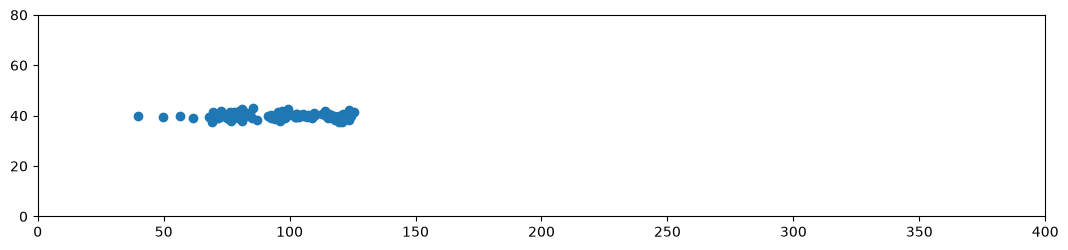

In [15]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.scatter(*path[::100].T)
ax.set_xlim(Q_MIN[0], Q_MAX[0])
ax.set_ylim(Q_MIN[1], Q_MAX[1])
ax.set(aspect='equal')
plt.show()